# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


Dataset shape: (13225, 90)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1534226092176355661,https://www.airbnb.com/rooms/1534226092176355661,20260627230126,2026-06-29,city scrape,Private Suite Oceanfront La Jolla,Private suite in Ocean front Estate in La Jolla,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,14064859,...,NaN,NaN,NaN,NaN,NaN,9,6,3,0,NaN
1,1151093362948878244,https://www.airbnb.com/rooms/1151093362948878244,20260627230126,2026-06-29,city scrape,Magical view,Luxury high rise building fully remodeled with...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,365015269,...,NaN,NaN,NaN,STR-08000L,NaN,1,1,0,0,NaN
2,46566873,https://www.airbnb.com/rooms/46566873,20260627230126,2026-06-28,city scrape,Highland on 60th Large 3BR 4 Beds/2 BA Near SDSU,Centrally located single-family home with a la...,NaN,https://a0.muscache.com/pictures/5b341abe-0010...,21897271,...,4.98,4.91,4.91,"STR-01411L, 644117",NaN,1,1,0,0,3.40
3,683340460312082362,https://www.airbnb.com/rooms/683340460312082362,20260627230126,2026-07-02,previous scrape,"Beautiful, Private Bed & Bath in Central Location",Keep it simple at this peaceful and centrally-...,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,21788590,...,5.00,4.95,5.00,"STR-06725L, 644561",NaN,2,1,1,0,0.45
4,50119879,https://www.airbnb.com/rooms/50119879,20260627230126,2026-06-29,city scrape,Wooden Craftsman Home w/ Private Backyard & Ga...,Make this entire space your new home away from...,NaN,https://a0.muscache.com/pictures/8b957cbc-f489...,117810403,...,4.93,4.98,4.79,"STR-06662L, 648042",NaN,1,1,0,0,0.95


## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

--- Top 20 Columns with the Most Missing Values ---
                              Missing Count  Percentage (%)
neighborhood_overview                 13225      100.000000
host_since                            13225      100.000000
host_response_time                    13225      100.000000
host_thumbnail_url                    13225      100.000000
host_acceptance_rate                  13225      100.000000
host_response_rate                    13225      100.000000
host_verifications                    13225      100.000000
neighbourhood                         13225      100.000000
host_total_listings_count             13225      100.000000
host_neighbourhood                    13225      100.000000
calendar_updated                      13225      100.000000
instant_bookable                      13225      100.000000
neighbourhood_group_cleansed          13225      100.000000
host_about                             4842       36.612476
license                                2986     

/tmp/ipykernel_798/2723477077.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df.head(15).index, y=missing_df.head(15)['Percentage (%)'], palette='viridis')


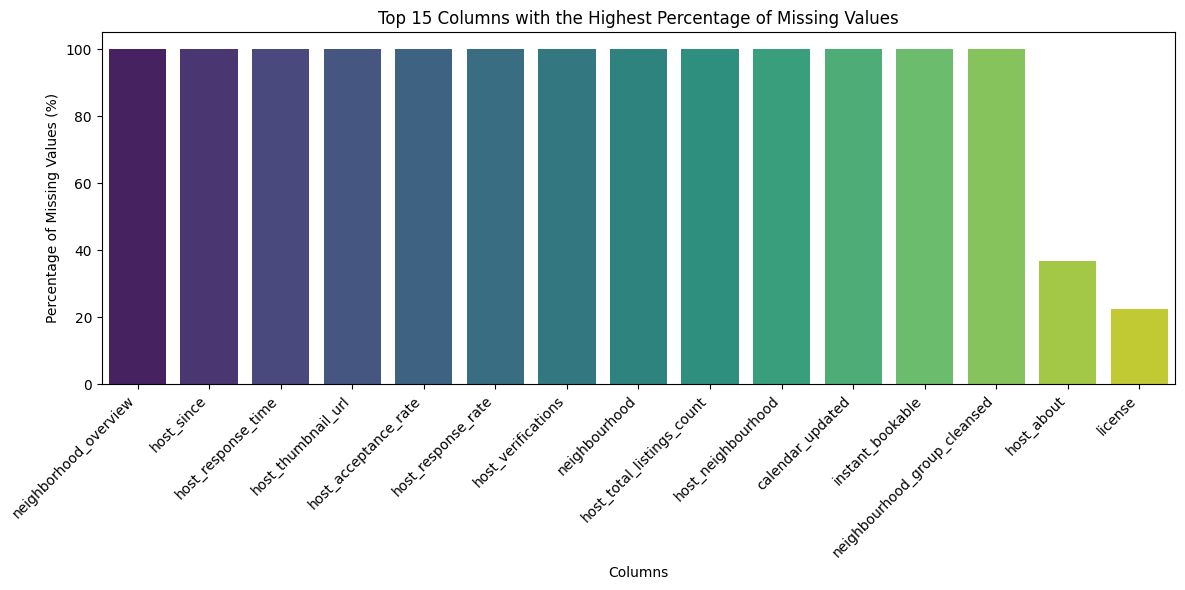

### Reflection:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?

### ✍️ Your Response: 🔧
1. neighborhood_overview, host_since, and host_response_time

2. license and host_response_time

3. host_total_listings_count, host_about, host_thumbnail_url


## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

New shape of dataset: (13225, 87)
Are any of the dropped columns still present? []
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13225 entries, 0 to 13224
Columns: 87 entries, id to reviews_per_month
dtypes: float64(40), int64(18), object(29)
memory usage: 8.8+ MB


### Reflection:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?

### ✍️ Your Response: 🔧
1. neighborhood_overview, host_since, calendar_updated

2. These columns do not contain any data or contributed anything to the business of AirBnB itself. They also don't contribute to the pricing or bookng behaviors of any of the users.

3. If you left that data in, it would just fill up storage, causing the system to slow down due to the extra amounts of memory that it uses. It can also cause confusion among team members because the stakeholders of the business may assume that the features contain valuable information and would waste time trying to use it.



## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

Missing values in 'host_about' remaining: 0
Missing values in 'review_scores_cleanliness' remaining: 0


### Reflection:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

### ✍️ Your Response: 🔧
1. host_about and review_scores_cleanliness

2. I used a placeholder by stating "no description provided" because a lot of the data is missing. If I were to remove all of the information, then I would lose some critical information. By adding a placeholder, it retains the usability without losing some important information. For the review_scores_cleanliness, I just filled in some of the missing values with the median of the other data, so nothing is skewed too much to the mins/maxs.

3. Biases, and for using the median score for review_scores_cleanliness, it would cover up the people who have had worse ratings for cleanliness in the past.


## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

Price Column Summary:
count    11856.000000
mean       483.802383
std        987.207536
min          5.500000
25%        175.457500
50%        322.920000
75%        589.000000
max      82340.820000
Name: price, dtype: float64


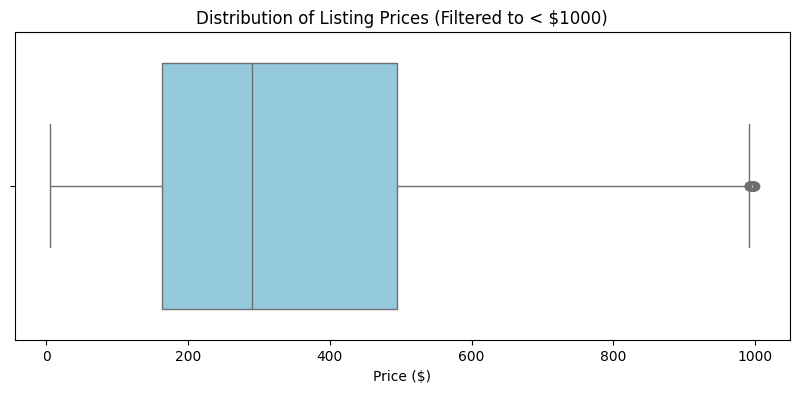

### Reflection: :
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?

### ✍️ Your Response: 🔧
1. Price

2. Format checking and character removal

3. It helps with calculating and data integrity. It removes any inconsistencies in the data so that everything is accurate and nothing is misinterpreted.

## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
- Remove duplicates if found

In [10]:
# 1. Check for exact duplicate rows in the entire dataset
exact_duplicates_count = df.duplicated().sum()
print(f"Number of exact duplicate rows: {exact_duplicates_count}")

# 2. Check for duplicate IDs (where the 'id' column should be unique)
duplicate_ids_count = df.duplicated(subset=['id']).sum()
print(f"Number of duplicate listing IDs: {duplicate_ids_count}")

# 3. Remove duplicates if found
if exact_duplicates_count > 0:
    df = df.drop_duplicates()
    print("Exact duplicate rows removed.")

if duplicate_ids_count > 0:
    df = df.drop_duplicates(subset=['id'], keep='first')
    print("Duplicate listing IDs removed (keeping the first occurrence).")

# 4. Verify the final shape of the dataset
print(f"Final dataset shape: {df.shape}")

Number of exact duplicate rows: 0
Number of duplicate listing IDs: 0
Final dataset shape: (13225, 87)


### Reflection:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?

### ✍️ Your Response: 🔧 🔧
1. No

2. If there are any duplicate records, I would've gotten rid of them because they offer no new information and distort the dataset

3. They are risky because counting the duplicates would inflate some metrics such as how many listings are avalable, average revenue across hosts, booking demand, etc.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```





In [11]:
df.to_csv('cleaned_airbnb_data_6.csv', index=False)
print("Dataset exported successfully!")

Dataset exported successfully!


## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### Reflection:
1. Which section of the assignment was the most challenging for you? What made it challenging? Was it the coding or the application of class concepts?
2. Look back at your assignment and discuss a time when you had to drop, fix, or keep a piece of data. Why was it necessary to drop, fix, or keep that specific piece of data? (e.x. dropping a column full of null values because it has no useful information)
3. What’s one way a business team (e.g., hosts, pricing analysts, app administrators) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1.  The most challenging part was Section 5, Convert and Clean Data Types because of the coding aspect. It required putting together strings in the price column using regular expressions and stripping symbols like $ and , before converting them to floats. It is a common but pretty hard task in pandas.
2.  I had to drop completely empty columns like neighborhood_overview and calendar_updated because they contained all missing values. Keeping them would waste system storage, increase the notebook's memory footprint, and mislead teammates into thinking these features held analytical value.
3. Pricing analysts would highly benefit from this cleaned version because the price column is now converted from strings into numerical values. They can immediately calculate average rental costs across different neighborhoods and run regression models to optimize pricing without errors.
4. I would explore the amenities column. Right now, it contains lists of amenities formatted as strings; parsing these into individual boolean columns like has_wifi, has_pool would allow us to analyze how specific amenities impact the listing price.
5. This aligns directly with my goal of mastering real-world data preparation. Being able to independently identify data discrepancies, select appropriate imputation methods, and write code to enforce correct data types prepares me to handle raw datasets in my future career as a business analyst. I am also intending to go into the real estate field, primarily the rental field, so this assignment is something that I will take away from this course.


## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_06_data_cleaning.ipynb"